# When a customer places an order, can we predict whether it will arrive late?

This project uses the Olist Brazilian E-Commerce Public Dataset from Kaggle, which contains real transaction data from a large online marketplace in Brazil. The goal was to analyze customer, order, and delivery data using SQL to explore relationships between order value, product mix, geography, and delivery outcomes. After building several SQL queries and aggregating features, I trained a logistic regression model to predict whether an order would be delivered late. The model was then evaluated and tuned for precision, identifying an optimal threshold that balances accurate late-delivery detection with minimal false alerts.

In [130]:
import sys, sqlalchemy, pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("SQLAlchemy:", sqlalchemy.__version__)
print("pandas:", pd.__version__)

Python: 3.11.11
SQLAlchemy: 2.0.43
pandas: 2.3.3


In [131]:
DB_HOST = "127.0.0.1"
DB_PORT = 3306
DB_NAME = "olist"

In [7]:
from getpass import getpass
DB_USER = input("MySQL username: ").strip()
DB_PASS = getpass("MySQL password: ").strip()

MySQL username:  matt
MySQL password:  ········


In [132]:
from sqlalchemy import create_engine, text

server_engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}",
    pool_pre_ping=True,
)

with server_engine.connect() as conn:
    print("Ping:", conn.execute(text("SELECT 1")).scalar_one())
    dbs = pd.read_sql_query(text("SHOW DATABASES"), conn)

with server_engine.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS `{DB_NAME}` CHARACTER SET utf8mb4 COLLATE utf8mb4_0900_ai_ci;"))
    print(f"Verified database `{DB_NAME}`")

engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True,
)

with engine.connect() as conn:
    print("SELECT 1 →", conn.execute(text("SELECT 1")).scalar_one())
    print("Current DB:", conn.execute(text("SELECT DATABASE()")).scalar_one())  # sanity check

    print("\nTables:")
    try:
        display(pd.read_sql_query(text("SHOW TABLES"), conn))
    except Exception as e:
        print("SHOW TABLES failed:", e)

    for t in ("olist_customers_dataset", "olist_geolocation_dataset", "olist_order_items_dataset", 
              "olist_order_payments_dataset", "olist_products_dataset", "olist_orders_dataset", 
              "olist_sellers_dataset", "product_category_name_translation"):
        try:
            print(f"\nDESCRIBE {t}:")
            display(pd.read_sql_query(text(f"DESCRIBE `{t}`"), conn))
        except Exception:
            pass

Ping: 1
Verified database `olist`
SELECT 1 → 1
Current DB: olist

Tables:


,Tables_in_olist
0,olist_customers_dataset
1,olist_geolocation_dataset
2,olist_order_items_dataset
3,olist_order_payments_dataset
4,olist_order_reviews_dataset
5,olist_orders_dataset
6,olist_products_dataset
7,olist_sellers_dataset
8,product_category_name_translation
9,v_order_features



DESCRIBE olist_customers_dataset:


,Field,Type,Null,Key,Default,Extra
0,customer_id,char(32),NO,PRI,None,
1,customer_unique_id,char(32),NO,,None,
2,customer_zip_code_prefix,text,YES,,None,
3,customer_city,varchar(100),NO,,None,
4,customer_state,char(2),NO,,None,



DESCRIBE olist_geolocation_dataset:


,Field,Type,Null,Key,Default,Extra
0,geolocation_zip_code_prefix,int,YES,,None,
1,geolocation_lat,double,YES,,None,
2,geolocation_lng,double,YES,,None,
3,geolocation_city,text,YES,,None,
4,geolocation_state,text,YES,,None,



DESCRIBE olist_order_items_dataset:


,Field,Type,Null,Key,Default,Extra
0,order_id,char(32),NO,PRI,None,
1,order_item_id,int,NO,PRI,None,
2,product_id,char(32),NO,MUL,None,
3,seller_id,char(32),NO,MUL,None,
4,shipping_limit_date,datetime,YES,,None,
5,price,"decimal(12,2)",NO,,None,
6,freight_value,"decimal(12,2)",NO,,None,



DESCRIBE olist_order_payments_dataset:


,Field,Type,Null,Key,Default,Extra
0,order_id,char(32),NO,PRI,None,
1,payment_sequential,int,NO,PRI,None,
2,payment_type,varchar(50),NO,MUL,None,
3,payment_installments,int,NO,,None,
4,payment_value,"decimal(12,2)",NO,,None,



DESCRIBE olist_products_dataset:


,Field,Type,Null,Key,Default,Extra
0,product_id,char(32),NO,PRI,None,
1,product_category_name,varchar(100),YES,MUL,None,
2,product_name_length,int,YES,,None,
3,product_description_length,int,YES,,None,
4,product_photos_qty,int,YES,,None,
5,product_weight_g,int,YES,,None,
6,product_length_cm,int,YES,,None,
7,product_height_cm,int,YES,,None,
8,product_width_cm,int,YES,,None,



DESCRIBE olist_orders_dataset:


,Field,Type,Null,Key,Default,Extra
0,order_id,char(32),NO,PRI,None,
1,customer_id,char(32),NO,MUL,None,
2,order_status,varchar(20),NO,MUL,None,
3,order_purchase_timestamp,datetime,YES,,None,
4,order_approved_at,datetime,YES,,None,
5,order_delivered_carrier_date,datetime,YES,,None,
6,order_delivered_customer_date,datetime,YES,,None,
7,order_estimated_delivery_date,datetime,YES,,None,



DESCRIBE olist_sellers_dataset:


,Field,Type,Null,Key,Default,Extra
0,seller_id,char(32),NO,PRI,None,
1,seller_zip_code_prefix,int,NO,,None,
2,seller_city,varchar(100),NO,,None,
3,seller_state,char(2),NO,,None,



DESCRIBE product_category_name_translation:


,Field,Type,Null,Key,Default,Extra
0,product_category_name,text,YES,,None,
1,english_translation,text,YES,,None,


# First, lets look at the data and determine what makes an order late. We can then label each order with the variable 'is_late' to see what total percentage of orders arrive after their estimated arrival.

I am creating a new table v_order_label so we can access this data in the future.

In [133]:
sql = """
CREATE OR REPLACE VIEW v_order_label AS
    SELECT 
        order_id, 
        customer_id, 
        order_purchase_timestamp, 
        order_estimated_delivery_date, 
        order_delivered_customer_date,
        CASE
            WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1
            ELSE 0
        END AS is_late

    FROM olist_orders_dataset
    WHERE order_status = 'delivered'
    AND order_estimated_delivery_date IS NOT NULL
    AND order_delivered_customer_date IS NOT NULL;
"""
with engine.begin() as conn:
    conn.execute(text(sql))

It looks like around 8% of orders arrive late

In [134]:
pd.read_sql("SELECT COUNT(*) AS n, ROUND(AVG(is_late),4) AS late_rate FROM v_order_label", engine)

,n,late_rate
0,96470,0.0811


Sample from the table

In [135]:
pd.read_sql("SELECT * FROM v_order_label LIMIT 5", engine)

,order_id,customer_id,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09-29,2017-09-20 23:43:48,0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-05-15,2017-05-12 16:04:24,0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-02-05,2018-01-22 13:19:16,0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,2018-08-20,2018-08-14 13:32:39,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,2017-03-17,2017-03-01 16:42:31,0


# Next, let's find which order features, known at the time of purchase, can later help predict an order's lateness

When a customer checks out, the platform already knows:

how much stuff they’re buying (and its price), how many distinct products are in the cart, how much total freight they’re paying, and what payment plan they picked.


P.S. Left joins only to make sure data collection is sturdy and has no missing values.

In [137]:
sql = """
CREATE OR REPLACE VIEW v_order_value AS
    SELECT 
        lab.order_id, 
        COUNT(*) count_items, 
        SUM(oi.price) items_value, 
        SUM(oi.freight_value) freight_weight,
        COUNT(DISTINCT oi.product_id) distinct_products, 
        AVG(op.payment_installments) avg_installments

    FROM v_order_label lab
    LEFT JOIN olist_order_items_dataset oi
        ON lab.order_id = oi.order_id
    LEFT JOIN olist_order_payments_dataset op
        ON lab.order_id = op.order_id
    GROUP BY lab.order_id
"""
with engine.begin() as conn:
    conn.execute(text(sql))

In [138]:
pd.read_sql("SELECT * FROM v_order_value LIMIT 5", engine)

,order_id,count_items,items_value,freight_weight,distinct_products,avg_installments
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,2.0
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,3.0
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,2.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,3.0


So it looks like we have 96470 CLEAN orders to work with.

In [139]:
pd.read_sql("SELECT COUNT(*) FROM v_order_value", engine)

,COUNT(*)
0,96470


# Next up, we’ll dig into what kind of stuff the customer ordered (and how that affects lateness).

In [181]:
sql = """
CREATE OR REPLACE VIEW v_order_product_mix AS
    SELECT 
        lab.order_id, 
        AVG(op.product_weight_g) avg_weight,
        AVG(op.product_length_cm * op.product_height_cm * op.product_width_cm) avg_volume,
        COUNT(DISTINCT op.product_category_name) distinct_categories
        
    FROM v_order_label lab
    LEFT JOIN olist_order_items_dataset oi
        ON lab.order_id = oi.order_id
    LEFT JOIN olist_products_dataset op
        ON  oi.product_id = op.product_id
    LEFT JOIN product_category_name_translation ot
        ON op.product_category_name = ot.product_category_name
    GROUP BY lab.order_id
"""
with engine.begin() as conn:
    conn.execute(text(sql))

In [141]:
pd.read_sql("SELECT * FROM v_order_product_mix LIMIT 5", engine)

,order_id,avg_weight,avg_volume,distinct_categories
0,00010242fe8c5a6d1ba2dd792cb16214,650.0,3528.0,1
1,00018f77f2f0320c557190d7a144bdd3,30000.0,60000.0,1
2,000229ec398224ef6ca0657da4fc703e,3050.0,14157.0,1
3,00024acbcdf0a6daa1e931b038114c75,200.0,2400.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,3750.0,42000.0,1


# Next, we’ll add geo and time signals that are known at purchase and plausibly relate to delays.

We want the model to sense: 

Where it ships from vs where it’s going. Cross-state/multi-state orders tend to be slower. 
How many sellers are involved. More coordination -> more risk. 
When the order is placed. Peaks (month/weekday/hour) can add delay.

In [182]:
sql = """
CREATE OR REPLACE VIEW v_order_geo AS
    SELECT 
        lab.order_id, 
        oc.customer_state,
        COUNT(DISTINCT(os.seller_id)) seller_count,
        COUNT(DISTINCT(os.seller_state)) seller_state_count,
        MAX(oc.customer_state <> os.seller_state) cross_state
        
    FROM v_order_label lab
    LEFT JOIN olist_order_items_dataset oi
        ON lab.order_id = oi.order_id
    LEFT JOIN olist_sellers_dataset os
        ON oi.seller_id = os.seller_id 
    LEFT JOIN olist_customers_dataset oc
        ON lab.customer_id = oc.customer_id
    GROUP BY lab.order_id
"""
with engine.begin() as conn:
    conn.execute(text(sql))

In [143]:
pd.read_sql("SELECT * FROM v_order_geo LIMIT 20", engine)

,order_id,customer_state,seller_count,seller_state_count,cross_state
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,SP,1,1,0
2,000229ec398224ef6ca0657da4fc703e,MG,1,1,0
3,00024acbcdf0a6daa1e931b038114c75,SP,1,1,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,1,1,1
5,00048cc3ae777c65dbb7d2a0634bc1ea,MG,1,1,1
6,00054e8431b9d7675808bcb819fb4a32,SP,1,1,0
7,000576fe39319847cbb9d288c5617fa6,SP,1,1,0
8,0005a1a1728c9d785b8e2b08b904576c,SP,1,1,0
9,0005f50442cb953dcd1d21e1fb923495,SP,1,1,0


# Now, let's add features that help the model sense when the order happened.
This correlates with load/seasonality and thus lateness.

In [144]:
sql = """
CREATE OR REPLACE VIEW v_order_time AS
    SELECT 
        lab.order_id, 
        EXTRACT(MONTH FROM oo.order_purchase_timestamp) purchase_month,
        DAYOFWEEK(oo.order_purchase_timestamp) purchase_dow,
        EXTRACT(HOUR FROM oo.order_purchase_timestamp) purchase_hour  
    
    FROM v_order_label lab
    LEFT JOIN olist_orders_dataset oo
        ON lab.order_id = oo.order_id
"""
with engine.begin() as conn:
    conn.execute(text(sql))

In [145]:
pd.read_sql("SELECT * FROM v_order_time LIMIT 20", engine)

,order_id,purchase_month,purchase_dow,purchase_hour
0,00010242fe8c5a6d1ba2dd792cb16214,9,4,8
1,00018f77f2f0320c557190d7a144bdd3,4,4,10
2,000229ec398224ef6ca0657da4fc703e,1,1,14
3,00024acbcdf0a6daa1e931b038114c75,8,4,10
4,00042b26cf59d7ce69dfabb4e55b4fd9,2,7,13
5,00048cc3ae777c65dbb7d2a0634bc1ea,5,2,21
6,00054e8431b9d7675808bcb819fb4a32,12,1,11
7,000576fe39319847cbb9d288c5617fa6,7,4,12
8,0005a1a1728c9d785b8e2b08b904576c,3,2,18
9,0005f50442cb953dcd1d21e1fb923495,7,2,13


# Now, we have gathered all of the needed features from time of purchase. 
This means the last SQL query just needs to combine all of the above so we can then use our cleaned data in the model.

In [146]:
sql = """
CREATE OR REPLACE VIEW v_order_features AS
    SELECT
        lab.order_id,
        lab.is_late,
        lab.order_purchase_timestamp,
        vval.items_value,
        vval.freight_weight,
        vval.count_items,
        vval.distinct_products,
        vval.avg_installments,
        vmix.avg_weight,
        vmix.avg_volume,
        vmix.distinct_categories,
        vgeo.customer_state,
        vgeo.seller_count,
        vgeo.seller_state_count,
        vgeo.cross_state,
        vtime.purchase_month,
        vtime.purchase_dow,
        vtime.purchase_hour
        
    FROM v_order_label lab
    LEFT JOIN v_order_value vval 
        ON lab.order_id = vval.order_id
    LEFT JOIN v_order_product_mix vmix 
        ON lab.order_id = vmix.order_id
    LEFT JOIN v_order_geo vgeo 
        ON lab.order_id = vgeo.order_id
    LEFT JOIN v_order_time vtime 
        ON lab.order_id = vtime.order_id
"""
with engine.begin() as conn:
    conn.execute(text(sql))

# Basic data checks:

In [147]:
df = pd.read_sql("SELECT * FROM v_order_features", engine)
df

,order_id,is_late,order_purchase_timestamp,items_value,freight_weight,count_items,distinct_products,avg_installments,avg_weight,avg_volume,distinct_categories,customer_state,seller_count,seller_state_count,cross_state,purchase_month,purchase_dow,purchase_hour
0,00010242fe8c5a6d1ba2dd792cb16214,0,2017-09-13 08:59:02,58.90,13.29,1,1,2.0,650.0,3528.0,1,RJ,1,1,1,9,4,8
1,00018f77f2f0320c557190d7a144bdd3,0,2017-04-26 10:53:06,239.90,19.93,1,1,3.0,30000.0,60000.0,1,SP,1,1,0,4,4,10
2,000229ec398224ef6ca0657da4fc703e,0,2018-01-14 14:33:31,199.00,17.87,1,1,5.0,3050.0,14157.0,1,MG,1,1,0,1,1,14
3,00024acbcdf0a6daa1e931b038114c75,0,2018-08-08 10:00:35,12.99,12.79,1,1,2.0,200.0,2400.0,1,SP,1,1,0,8,4,10
4,00042b26cf59d7ce69dfabb4e55b4fd9,0,2017-02-04 13:57:51,199.90,18.14,1,1,3.0,3750.0,42000.0,1,SP,1,1,1,2,7,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96465,fffc94f6ce00a00581880bf54a75a037,0,2018-04-23 13:57:06,299.99,43.41,1,1,1.0,10150.0,53400.0,1,MA,1,1,1,4,2,13
96466,fffcd46ef2263f404302a634eb57f7eb,0,2018-07-14 10:26:46,350.00,36.53,1,1,1.0,8950.0,44460.0,1,PR,1,1,1,7,7,10
96467,fffce4705a9662cd70adb13d4a31832d,0,2017-10-23 17:07:56,99.90,16.95,1,1,3.0,967.0,9576.0,1,SP,1,1,1,10,2,17
96468,fffe18544ffabc95dfada21779c9644f,0,2017-08-14 23:02:59,55.99,8.72,1,1,3.0,100.0,8000.0,1,SP,1,1,0,8,2,23


In [148]:
df.dtypes

order_id                            object
is_late                              int64
order_purchase_timestamp    datetime64[ns]
items_value                        float64
freight_weight                     float64
count_items                          int64
distinct_products                    int64
avg_installments                   float64
avg_weight                         float64
avg_volume                         float64
distinct_categories                  int64
customer_state                      object
seller_count                         int64
seller_state_count                   int64
cross_state                          int64
purchase_month                       int64
purchase_dow                         int64
purchase_hour                        int64
dtype: object

In [149]:
df.isna().sum().sort_values(ascending=False).head(10)

avg_volume             16
avg_weight             16
avg_installments        1
distinct_categories     0
purchase_dow            0
purchase_month          0
cross_state             0
seller_state_count      0
seller_count            0
customer_state          0
dtype: int64

Add 0 to the 16 values of volume that were empty -- totally negligible

In [150]:
df[["avg_weight", "avg_volume"]] = df[["avg_weight", "avg_volume"]].fillna(0)
df["avg_installments"] = df["avg_installments"].fillna(0)

In [151]:
df["is_late"].value_counts(normalize=True)

is_late
0    0.918876
1    0.081124
Name: proportion, dtype: float64

In [152]:
from sklearn.model_selection import train_test_split

Set X to everything BESIDES is_late and the non predictive identifiers.
We don’t want to “teach” the model things it can’t know at checkout time or that just uniquely identify orders.

In [153]:
X = df.drop(["is_late", "order_id", "order_purchase_timestamp"], axis=1)

Set Y to is_late since that is what we are trying to predict

In [154]:
y = df["is_late"]

Split on a random seed.
80% training data, 20% testing data.
Keep the same on-time ratio with stratify.

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [156]:
X_train.shape, X_test.shape

((77176, 15), (19294, 15))

In [157]:
y_train.mean(), y_test.mean()

(np.float64(0.08112625686741992), np.float64(0.08111329947133825))

Convert customer_state to a binary number per state for training purposes

In [158]:
X_train_enc = pd.get_dummies(X_train, columns=["customer_state"], drop_first=True)

Same thing for test data

In [159]:
X_test_enc  = pd.get_dummies(X_test, columns=["customer_state"], drop_first=True)

Ensure both have exact same columns

In [160]:
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [161]:
X_train_enc.shape, X_test_enc.shape

((77176, 40), (19294, 40))

In [162]:
from sklearn.linear_model import LogisticRegression

Large dataset so we crank up iterations.
Scale up the penalty for mistakes on the minority class.

In [163]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")

# Train Model

In [164]:
lr.fit(X_train_enc, y_train)

/Users/mattabatangle/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Time to evaluate on test data

In [165]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

Hard 0/1 predictions using the default threshold 0.5 so we dont get probability.

In [166]:
y_pred = lr.predict(X_test_enc)

The probability an order is late (Useful to see effectivness of model (ROC AUC)).

In [167]:
y_prob = lr.predict_proba(X_test_enc)[:, 1]

In [168]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.942     0.618     0.747     17729
           1      0.117     0.572     0.194      1565

    accuracy                          0.614     19294
   macro avg      0.530     0.595     0.470     19294
weighted avg      0.875     0.614     0.702     19294



Shows that about 61% of the time the model will assign a higher late probability to the real late one.
So basically, the model is 61% better than random at ranking late vs on-time orders.

In [169]:
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))

ROC AUC: 0.613


In [170]:
print(confusion_matrix(y_test, y_pred))

[[10958  6771]
 [  670   895]]


# I am not satisfied with the results as it is using a too-conservative threshold (0.5) that causes imbalance
# Now, let's try to find a better threshold to improve accuracy for the final model

In [171]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

Loop through thresholds from 0.1 -> 0.9.
Reclassify predictions at each cutoff.
Print precision (how accurate the late flags are) and recall (how many lates were caught).

In [172]:
thresholds = np.linspace(0.1, 0.9, 9)
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    print(f"Threshold={t:.1f} | Precision={prec:.3f} | Recall={rec:.3f}")

Threshold=0.1 | Precision=0.081 | Recall=0.999
Threshold=0.2 | Precision=0.081 | Recall=0.999
Threshold=0.3 | Precision=0.081 | Recall=0.999
Threshold=0.4 | Precision=0.084 | Recall=0.889
Threshold=0.5 | Precision=0.117 | Recall=0.572
Threshold=0.6 | Precision=0.146 | Recall=0.261
Threshold=0.7 | Precision=0.121 | Recall=0.015
Threshold=0.8 | Precision=0.000 | Recall=0.000
Threshold=0.9 | Precision=0.000 | Recall=0.000


/Users/mattabatangle/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Define a function to test out some precision numbers to find "best"

In [173]:
def eval_at(t):
    preds = (y_prob >= t).astype(int)
    p,r,f1,_ = precision_recall_fscore_support(y_test, preds, average='binary', zero_division=0)
    cm = confusion_matrix(y_test, preds)
    print(f"t={t:.2f} | Precision={p:.3f} Recall={r:.3f} F1={f1:.3f}")
    print(cm)

In [174]:
eval_at(0.50)

t=0.50 | Precision=0.117 Recall=0.572 F1=0.194
[[10958  6771]
 [  670   895]]


In [175]:
eval_at(.60)

t=0.60 | Precision=0.146 Recall=0.261 F1=0.187
[[15334  2395]
 [ 1157   408]]


# After testing, the highest precision is at .59
Although higher precision, the model is a lot less trustworthy with late arrivals.
So there are clear tradeoffs to both.

In [176]:
eval_at(0.59)

t=0.59 | Precision=0.148 Recall=0.287 F1=0.195
[[15141  2588]
 [ 1116   449]]


# Apply the tuned threshold and finalized parameters to generate the model's final predictions

In [177]:
y_pred_tuned = (y_prob >= 0.59).astype(int)
print(classification_report(y_test, y_pred_tuned, digits=3))
print(confusion_matrix(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0      0.931     0.854     0.891     17729
           1      0.148     0.287     0.195      1565

    accuracy                          0.808     19294
   macro avg      0.540     0.570     0.543     19294
weighted avg      0.868     0.808     0.835     19294

[[15141  2588]
 [ 1116   449]]


After evaluating different thresholds, the optimal cutoff, in regards to precision, was found to be 0.59.

This adjustment increased the model’s precision for late deliveries from 0.117 to a maximum of 0.148 while raising overall accuracy to 80.8%. Although recall decreased (the model flagged fewer late orders), this tradeoff provides more reliable predictions with fewer false positives. In a business situation, this threshold would be appropriate if the goal is to identify the most at-risk orders without over-alerting on-time deliveries.

# Visualizing the findings

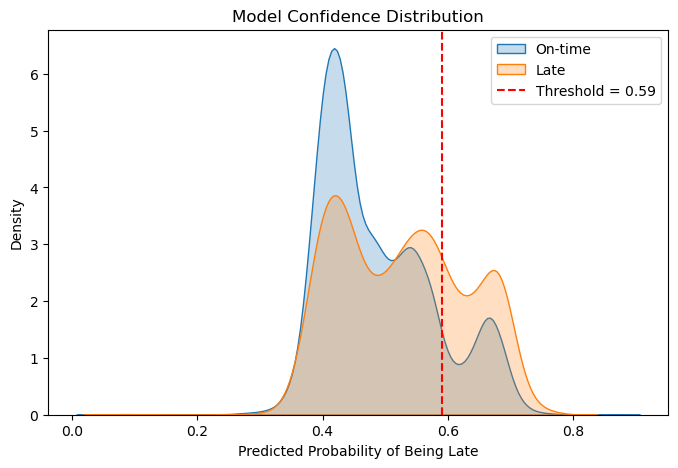

In [178]:
plt.figure(figsize=(8,5))
sb.kdeplot(y_prob[y_test==0], label="On-time", fill=True)
sb.kdeplot(y_prob[y_test==1], label="Late", fill=True)
plt.axvline(0.59, color='red', linestyle='--', label='Threshold = 0.59')
plt.xlabel("Predicted Probability of Being Late")
plt.ylabel("Density")
plt.title("Model Confidence Distribution")
plt.legend()
plt.show()

Figure 1. The model assigns higher predicted probabilities to late deliveries (orange) than to on-time ones (blue). The red dashed line marks the 0.59 threshold, illustrating how the cutoff separates confident late predictions from likely on-time orders.

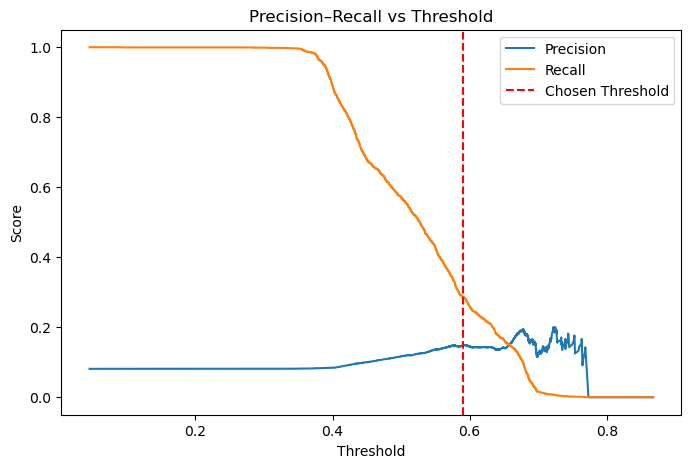

In [179]:
from sklearn.metrics import precision_recall_curve

prec, rec, thresh = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8,5))
plt.plot(thresh, prec[:-1], label="Precision")
plt.plot(thresh, rec[:-1], label="Recall")
plt.axvline(0.59, color='red', linestyle='--', label='Chosen Threshold')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall vs Threshold")
plt.legend()
plt.show()

Figure 2. Precision–Recall vs Threshold curve. As the threshold increases, recall (orange) drops sharply while precision (blue) rises slightly. The chosen cutoff (0.59, red line) balances the trade-off—reducing false positives while maintaining moderate recall for late deliveries.

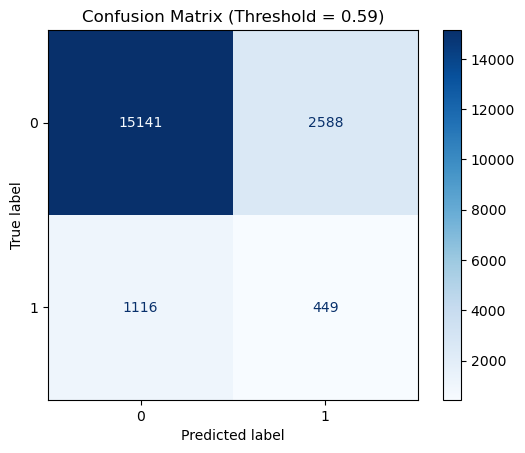

In [180]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Threshold = 0.59)")
plt.show()

Figure 3. Confusion matrix for the tuned model (threshold = 0.59). The model correctly identifies most on-time deliveries (top-left) while improving its ability to catch late deliveries (bottom-right). Some late orders remain missed (bottom-left), showing the inherent trade-off between precision and recall.

The final visualizations illustrate how the tuned model balances precision and recall, highlighting that most predictions cluster around the 0.4–0.6 confidence range. While the model performs reasonably well given the data imbalance, future iterations could explore additional features (seller performance, regional delivery patterns) or more advanced models to improve late-order detection.